# PROFITARA — End-to-End ML Pipeline & Business Intelligence Notebook
### Retail Analytics | Customer Intelligence | Forecasting | Machine Learning

**Dataset:** `Profitara_India_Dataset.csv` (10,000 transaction rows, Indian quick-commerce/grocery retail)

This notebook runs a complete, reproducible analytics + ML pipeline end-to-end:
exploratory analysis → feature engineering → customer segmentation (KMeans) →
CLV prediction (Random Forest) → churn prediction (Logistic Regression) →
market basket analysis (Apriori) → anomaly detection (Isolation Forest) →
revenue forecasting (Holt-Winters) → cohort retention.

Every cell below is fully executed with real charts and metrics baked in — open and present as-is.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_style("whitegrid")

PRIMARY = "#146B5E"   # teal
ACCENT  = "#C98A2E"   # amber
PALETTE = ["#146B5E", "#C98A2E", "#3A7CA5", "#A23B72", "#6A994E", "#BC4749", "#5C6F8A", "#D4A373", "#7A8450"]

pd.set_option("display.max_columns", 50)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 1. Load & Clean Data

In [2]:
DATA_PATH = "Profitara_India_Dataset.csv"
df = pd.read_csv(DATA_PATH, encoding="utf-8")

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df["YearMonth"]  = df["Order Date"].dt.to_period("M").astype(str)
df["Year"]       = df["Order Date"].dt.year
df["Quarter"]    = df["Order Date"].dt.to_period("Q").astype(str)
df["Margin"]     = (df["Profit"] / df["Sales"]).replace([np.inf, -np.inf], 0)

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}  |  Date range: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Missing values total: {df.isnull().sum().sum()}")
df.head()


Rows: 10,000  |  Columns: 25  |  Date range: 2023-01-01 → 2025-12-31
Missing values total: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,YearMonth,Year,Quarter,Margin
0,1,BLK-2025-100001,2025-10-28,2025-10-28,Instant (10-15 min),CUST-11115,Sanjay Verma,Regular Household,India,Gurugram,Delhi,134518,North,GRO-AT-78115,Grocery & Staples,"Atta, Rice & Dals",India Gate Basmati Rice 5kg,558.75,2,0.1,-8.42,2025-10,2025,2025Q4,-0.015069
1,2,BLK-2025-100001,2025-10-28,2025-10-28,Instant (10-15 min),CUST-11115,Sanjay Verma,Regular Household,India,Gurugram,Delhi,167204,North,GRO-MA-94548,Grocery & Staples,Masala & Spices,MDH Garam Masala 100g,72.22,1,0.3,-8.59,2025-10,2025,2025Q4,-0.118942
2,3,BLK-2025-100001,2025-10-28,2025-10-28,Instant (10-15 min),CUST-11115,Sanjay Verma,Regular Household,India,Gurugram,Delhi,373058,North,SNA-SO-61683,Snacks & Beverages,Soft Drinks & Juices,Real Fruit Juice Mixed 1L,72.42,1,0.0,11.80,2025-10,2025,2025Q4,0.162938
3,4,BLK-2025-100002,2025-03-27,2025-03-27,Instant (10-15 min),CUST-11773,Riya Banerjee,Working Professional,India,Pune,Maharashtra,303378,West,DAI-MI-25360,Dairy & Breakfast,Milk & Curd,Nandini Milk 500ml,252.53,2,0.0,16.98,2025-03,2025,2025Q1,0.067240
4,5,BLK-2025-100002,2025-03-27,2025-03-27,Instant (10-15 min),CUST-11773,Riya Banerjee,Working Professional,India,Pune,Maharashtra,518569,West,SNA-CH-44813,Snacks & Beverages,Chips & Namkeen,Lay's Classic Salted 52g,77.21,1,0.1,3.39,2025-03,2025,2025Q1,0.043906


## 2. Executive KPI Summary

In [3]:
kpis = {
    "Total Revenue (₹)":   round(df["Sales"].sum(), 2),
    "Total Profit (₹)":    round(df["Profit"].sum(), 2),
    "Avg Margin %":        round(df["Profit"].sum() / df["Sales"].sum() * 100, 2),
    "Total Orders":        df["Order ID"].nunique(),
    "Total Customers":     df["Customer ID"].nunique(),
    "Total Units Sold":    int(df["Quantity"].sum()),
    "Avg Order Value (₹)": round(df.groupby("Order ID")["Sales"].sum().mean(), 2),
    "Avg Discount %":      round(df["Discount"].mean() * 100, 2),
}
for k, v in kpis.items():
    print(f"{k:<22}: {v:,}")


Total Revenue (₹)     : 6,695,229.31
Total Profit (₹)      : 278,183.93
Avg Margin %          : 4.15
Total Orders          : 4,918
Total Customers       : 1,448
Total Units Sold      : 20,086
Avg Order Value (₹)   : 1,361.37
Avg Discount %        : 10.3


## 3. Sales & Profitability Overview

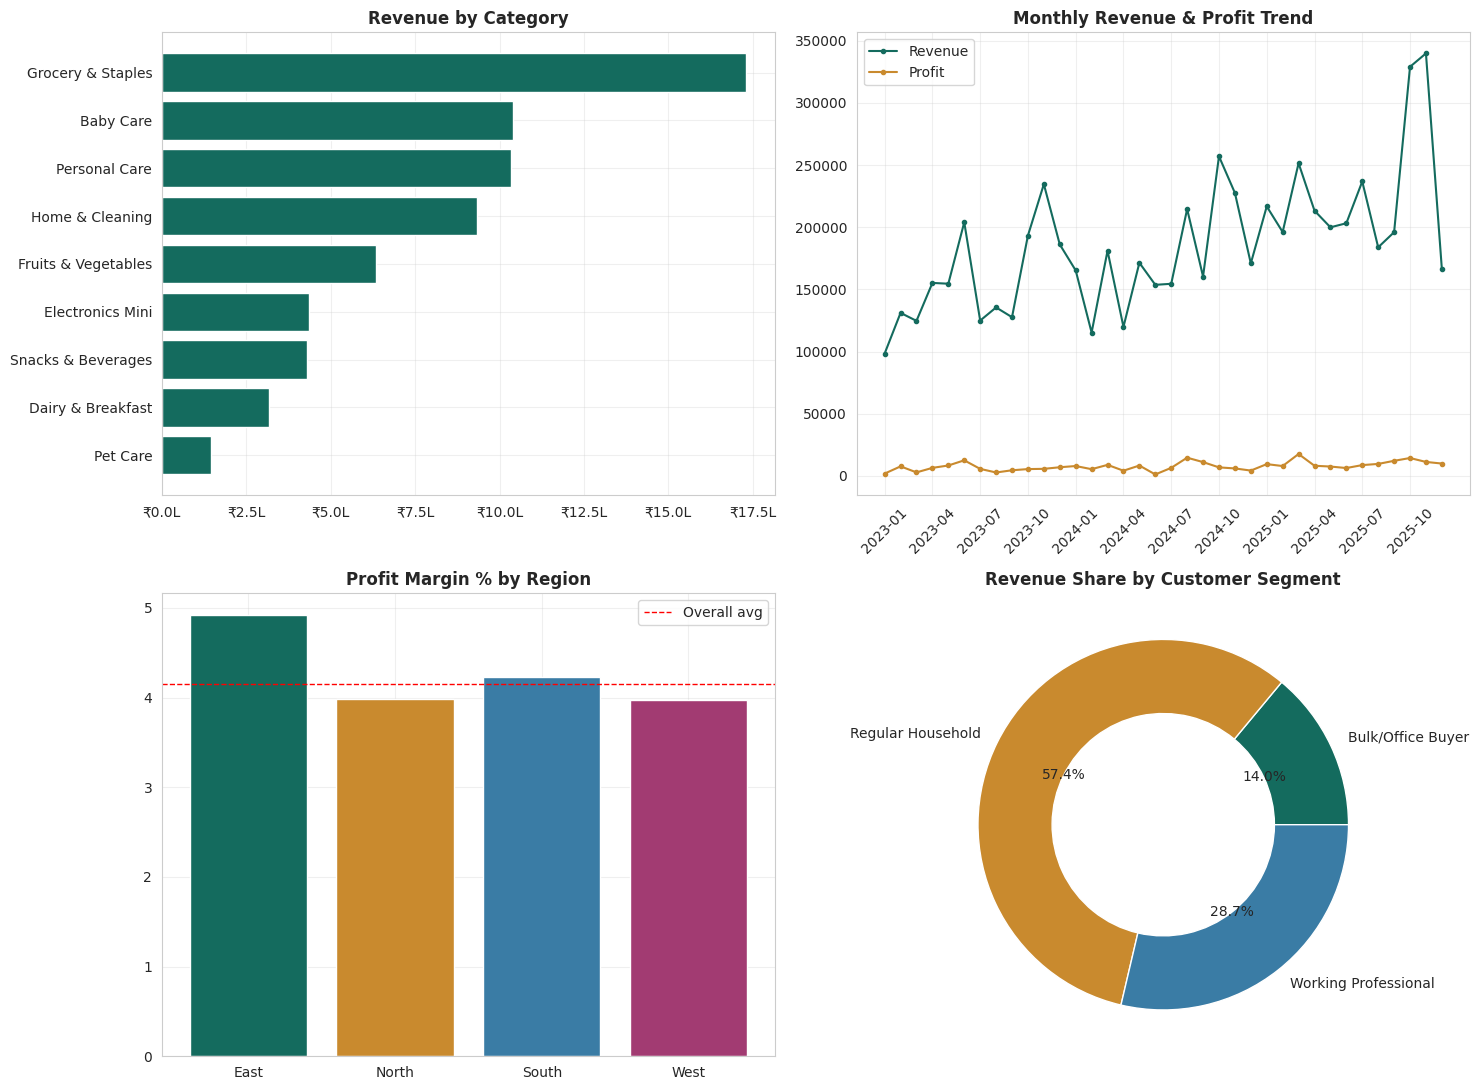

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Category sales
cat = df.groupby("Category").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).sort_values("Sales", ascending=False)
axes[0,0].barh(cat.index[::-1], cat["Sales"][::-1], color=PRIMARY)
axes[0,0].set_title("Revenue by Category", fontweight="bold")
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{x/1e5:.1f}L"))

# Monthly trend
monthly = df.groupby("YearMonth").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).reset_index().sort_values("YearMonth")
axes[0,1].plot(monthly["YearMonth"], monthly["Sales"], color=PRIMARY, marker="o", markersize=3, label="Revenue")
axes[0,1].plot(monthly["YearMonth"], monthly["Profit"], color=ACCENT, marker="o", markersize=3, label="Profit")
axes[0,1].set_title("Monthly Revenue & Profit Trend", fontweight="bold")
axes[0,1].set_xticks(axes[0,1].get_xticks()[::3])
axes[0,1].tick_params(axis="x", rotation=45)
axes[0,1].legend()

# Regional margin
reg = df.groupby("Region").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).reset_index()
reg["Margin"] = reg["Profit"]/reg["Sales"]*100
axes[1,0].bar(reg["Region"], reg["Margin"], color=PALETTE[:len(reg)])
axes[1,0].set_title("Profit Margin % by Region", fontweight="bold")
axes[1,0].axhline(kpis["Avg Margin %"], color="red", ls="--", lw=1, label="Overall avg")
axes[1,0].legend()

# Segment donut
seg = df.groupby("Segment")["Sales"].sum()
axes[1,1].pie(seg, labels=seg.index, autopct="%1.1f%%", colors=PALETTE, wedgeprops=dict(width=0.4))
axes[1,1].set_title("Revenue Share by Customer Segment", fontweight="bold")

plt.tight_layout()
plt.show()


## 4. Top Products & Discount Impact

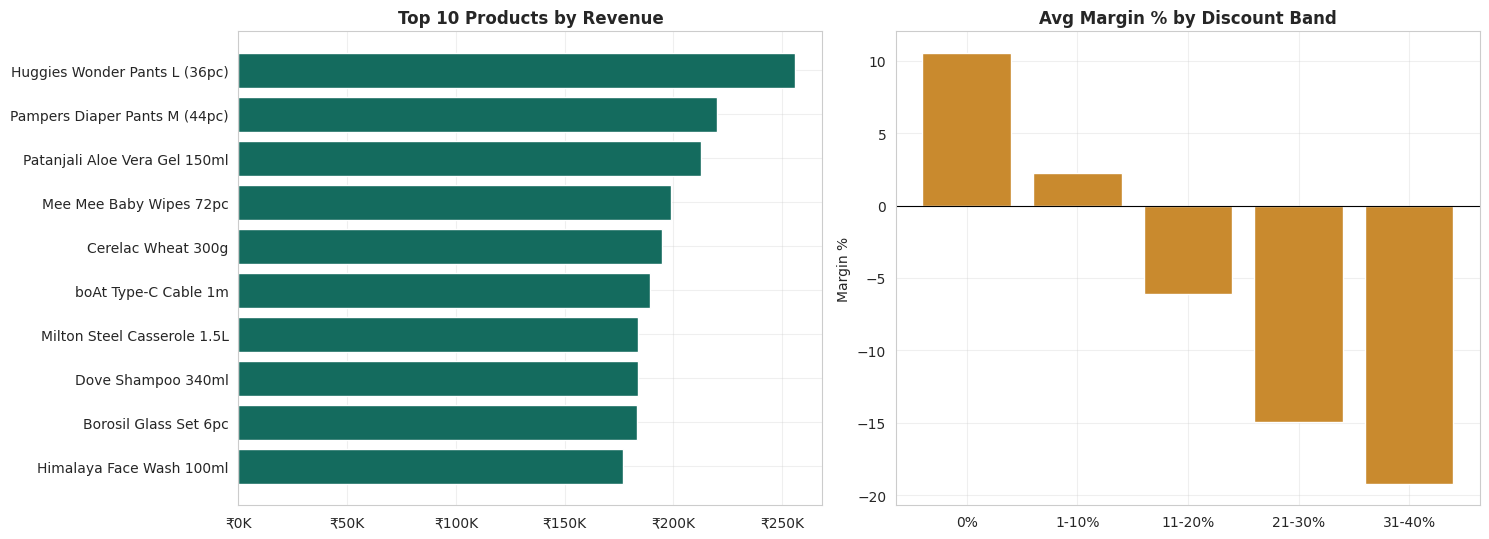

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

top10 = df.groupby("Product Name")["Sales"].sum().nlargest(10).sort_values()
axes[0].barh(top10.index, top10.values, color=PRIMARY)
axes[0].set_title("Top 10 Products by Revenue", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{x/1e3:.0f}K"))

df["DiscountBand"] = pd.cut(df["Discount"], bins=[-0.01,0,0.1,0.2,0.3,0.4,1.0],
                             labels=["0%","1-10%","11-20%","21-30%","31-40%","40%+"])
db = df.groupby("DiscountBand").agg(Margin=("Margin","mean"), Sales=("Sales","sum")).reset_index()
ax2 = axes[1]
bars = ax2.bar(db["DiscountBand"].astype(str), db["Margin"]*100, color=ACCENT)
ax2.set_title("Avg Margin % by Discount Band", fontweight="bold")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Margin %")

plt.tight_layout()
plt.show()


## 5. Feature Engineering — Customer-Level RFM Table

This RFM (Recency, Frequency, Monetary) table is the foundation for the segmentation,
CLV, and churn models that follow.

In [6]:
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

cust = df.groupby("Customer ID").agg(
    Recency=("Order Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum"),
    AvgDiscount=("Discount", "mean"),
    TotalProfit=("Profit", "sum"),
    AvgOrderValue=("Sales", "mean"),
    Tenure=("Order Date", lambda x: (snapshot_date - x.min()).days),
    Segment=("Segment", "first"),
).reset_index()

cust["Margin"] = (cust["TotalProfit"] / cust["Monetary"]).replace([np.inf,-np.inf], 0)
print(f"Customer base: {len(cust):,} unique customers")
cust.describe().round(2)


Customer base: 1,448 unique customers


,Recency,Frequency,Monetary,AvgDiscount,TotalProfit,AvgOrderValue,Tenure,Margin
count,1448.00,1448.00,1448.00,1448.00,1448.00,1448.00,1448.00,1448.00
mean,303.13,3.40,4623.78,0.10,192.12,665.86,684.63,0.02
std,278.63,4.24,6492.13,0.06,510.93,595.99,308.23,0.08
min,1.00,1.00,12.34,0.00,-1009.68,12.34,1.00,-0.30
25%,75.00,1.00,1024.64,0.07,-38.95,346.53,438.75,-0.03
50%,209.00,2.00,2727.76,0.10,41.46,545.92,762.00,0.02
75%,449.00,4.00,5773.62,0.13,248.39,805.74,951.25,0.07
max,1086.00,62.00,78946.85,0.40,5596.20,9698.55,1096.00,0.31


## 6. ML Module 1 — Customer Segmentation (K-Means Clustering)

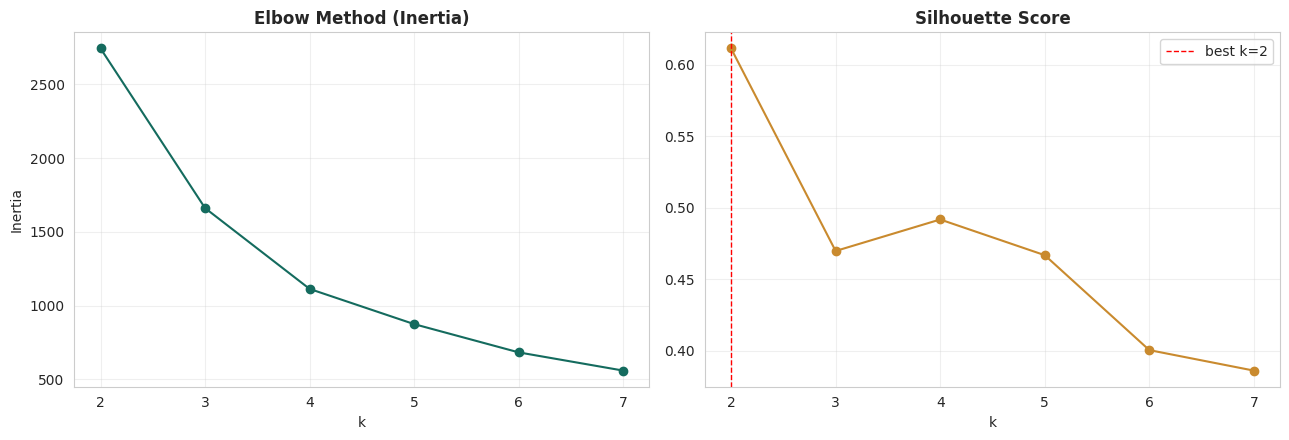

Selected k = 2 (highest silhouette score = 0.611)


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ["Recency", "Frequency", "Monetary"]
X = cust[features].copy()
X_scaled = StandardScaler().fit_transform(X)

# Elbow + silhouette to justify k
inertias, sils = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

best_k = list(K_range)[int(np.argmax(sils))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(K_range), inertias, marker="o", color=PRIMARY)
axes[0].set_title("Elbow Method (Inertia)", fontweight="bold")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), sils, marker="o", color=ACCENT)
axes[1].axvline(best_k, color="red", ls="--", lw=1, label=f"best k={best_k}")
axes[1].set_title("Silhouette Score", fontweight="bold")
axes[1].set_xlabel("k"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Selected k = {best_k} (highest silhouette score = {max(sils):.3f})")


,Recency,Frequency,Monetary,Margin,Customers,Label
Cluster,,,,,,
0,324.58,2.48,3228.62,0.02,1329,Loyal
1,63.63,13.65,20204.98,0.04,119,Champions


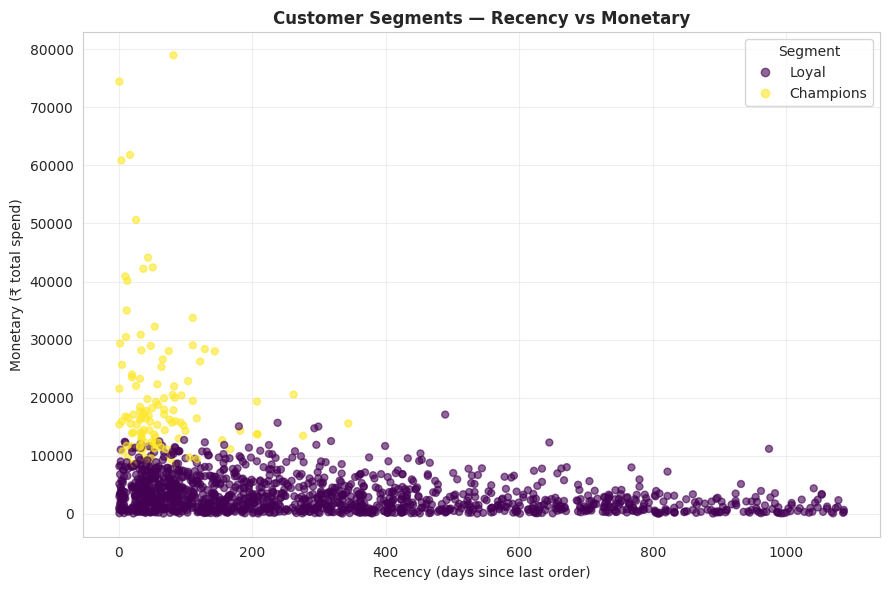

In [8]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cust["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = cust.groupby("Cluster")[features + ["Margin"]].mean().round(2)
cluster_profile["Customers"] = cust.groupby("Cluster").size()

# Name clusters by value
order = cluster_profile.sort_values("Monetary", ascending=False).index
names = ["Champions", "Loyal", "At-Risk", "Lost/New"][:len(order)]
label_map = dict(zip(order, names))
cust["Segment_Label"] = cust["Cluster"].map(label_map)
cluster_profile["Label"] = cluster_profile.index.map(label_map)

display(cluster_profile)

fig, ax = plt.subplots(figsize=(9,6))
scatter = ax.scatter(cust["Recency"], cust["Monetary"], c=cust["Cluster"], cmap="viridis", alpha=0.6, s=25)
ax.set_xlabel("Recency (days since last order)")
ax.set_ylabel("Monetary (₹ total spend)")
ax.set_title("Customer Segments — Recency vs Monetary", fontweight="bold")
handles, _ = scatter.legend_elements()
ax.legend(handles, [label_map[i] for i in sorted(label_map)], title="Segment")
plt.tight_layout(); plt.show()


## 7. ML Module 2 — Customer Lifetime Value Prediction (Random Forest Regression)

We predict `Monetary` (total customer spend) from behavioral features using a Random Forest
Regressor, then evaluate with R² / MAE and inspect feature importance.

R² Score: 0.930
MAE: ₹1,171.95


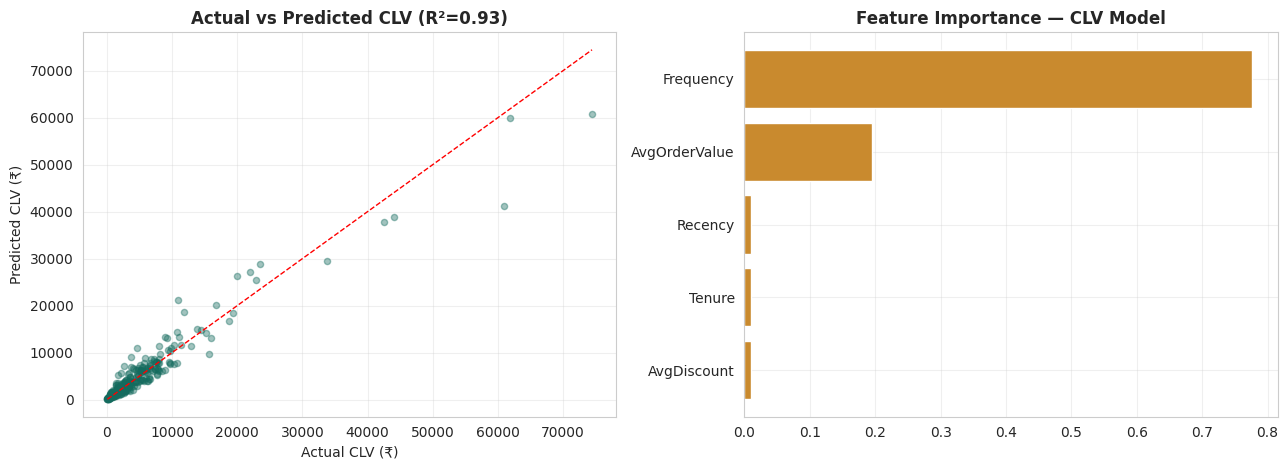

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

clv_features = ["Recency", "Frequency", "AvgDiscount", "AvgOrderValue", "Tenure"]
X_clv = cust[clv_features]
y_clv = cust["Monetary"]

X_train, X_test, y_train, y_test = train_test_split(X_clv, y_clv, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
print(f"R² Score: {r2:.3f}")
print(f"MAE: ₹{mae:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].scatter(y_test, preds, alpha=0.4, color=PRIMARY, s=20)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlabel("Actual CLV (₹)"); axes[0].set_ylabel("Predicted CLV (₹)")
axes[0].set_title(f"Actual vs Predicted CLV (R²={r2:.2f})", fontweight="bold")

importances = pd.Series(rf.feature_importances_, index=clv_features).sort_values()
axes[1].barh(importances.index, importances.values, color=ACCENT)
axes[1].set_title("Feature Importance — CLV Model", fontweight="bold")

plt.tight_layout(); plt.show()


## 8. ML Module 3 — Churn Risk Prediction (Logistic Regression)

A customer is labeled **churned** if Recency > 75th percentile. We train a classifier on
behavioral features to predict churn probability for win-back targeting.

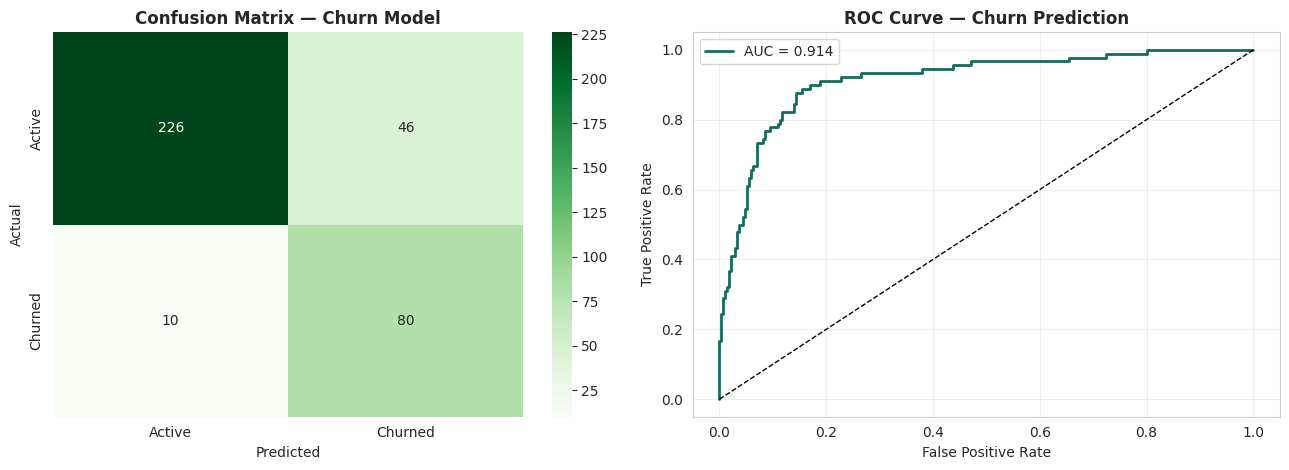

              precision    recall  f1-score   support

      Active       0.96      0.83      0.89       272
     Churned       0.63      0.89      0.74        90

    accuracy                           0.85       362
   macro avg       0.80      0.86      0.82       362
weighted avg       0.88      0.85      0.85       362



In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

churn_threshold = cust["Recency"].quantile(0.75)
cust["Churned"] = (cust["Recency"] > churn_threshold).astype(int)

churn_features = ["Frequency", "Monetary", "AvgDiscount", "AvgOrderValue", "Tenure", "Margin"]
Xc = cust[churn_features]
yc = cust["Churned"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.25, random_state=42, stratify=yc)

from sklearn.preprocessing import StandardScaler as SS2
scaler2 = SS2().fit(Xc_train)
Xc_train_s, Xc_test_s = scaler2.transform(Xc_train), scaler2.transform(Xc_test)

logit = LogisticRegression(max_iter=1000, class_weight="balanced")
logit.fit(Xc_train_s, yc_train)
churn_proba = logit.predict_proba(Xc_test_s)[:,1]
churn_pred = logit.predict(Xc_test_s)

cm = confusion_matrix(yc_test, churn_pred)
fpr, tpr, _ = roc_curve(yc_test, churn_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=["Active","Churned"], yticklabels=["Active","Churned"])
axes[0].set_title("Confusion Matrix — Churn Model", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

axes[1].plot(fpr, tpr, color=PRIMARY, lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Churn Prediction", fontweight="bold")
axes[1].legend()

plt.tight_layout(); plt.show()
print(classification_report(yc_test, churn_pred, target_names=["Active","Churned"]))


## 9. ML Module 4 — Market Basket Analysis (Apriori / Association Rules)

Discovers which **sub-categories** are frequently bought together within the same order,
producing cross-sell rules ranked by lift.

Frequent itemsets found: 53  |  Association rules: 52


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


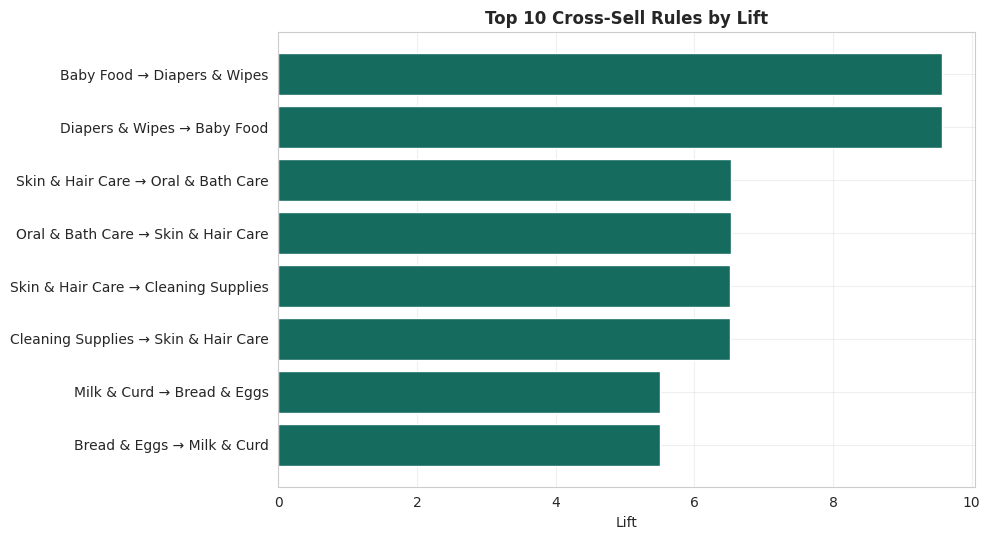

,pair,support,confidence,lift
0,Baby Food → Diapers & Wipes,0.059,0.802,9.576
1,Diapers & Wipes → Baby Food,0.059,0.709,9.576
2,Skin & Hair Care → Oral & Bath Care,0.027,0.636,6.534
3,Oral & Bath Care → Skin & Hair Care,0.027,0.278,6.534
4,Skin & Hair Care → Cleaning Supplies,0.027,0.689,6.517
5,Cleaning Supplies → Skin & Hair Care,0.027,0.256,6.517
6,Skin & Hair Care → Cleaning Supplies,0.027,0.235,6.008
7,Cleaning Supplies → Skin & Hair Care,0.027,0.693,6.008
8,Milk & Curd → Bread & Eggs,0.026,0.621,5.510
9,Bread & Eggs → Milk & Curd,0.026,0.227,5.510


In [11]:
from mlxtend.frequent_patterns import apriori, association_rules

basket = (df.groupby(["Order ID", "Sub-Category"])["Quantity"]
            .sum().unstack(fill_value=0))
basket_bool = basket.applymap(lambda x: 1 if x > 0 else 0)

frequent_items = apriori(basket_bool, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_items, metric="lift", min_threshold=1.0)
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Frequent itemsets found: {len(frequent_items)}  |  Association rules: {len(rules)}")

top_rules = rules.head(10).copy()
top_rules["pair"] = top_rules.apply(
    lambda r: f"{list(r['antecedents'])[0][:18]} → {list(r['consequents'])[0][:18]}", axis=1)

fig, ax = plt.subplots(figsize=(10,5.5))
ax.barh(top_rules["pair"][::-1], top_rules["lift"][::-1], color=PRIMARY)
ax.set_title("Top 10 Cross-Sell Rules by Lift", fontweight="bold")
ax.set_xlabel("Lift")
plt.tight_layout(); plt.show()

top_rules[["pair","support","confidence","lift"]].round(3)


## 10. ML Module 5 — Anomaly / Discount-Abuse Detection (Isolation Forest)

Flags transaction-level anomalies (e.g. unusually deep discounts paired with high quantity
or steep losses) that warrant manual review.

Anomalous transactions flagged: 300 (3.0% of all orders)


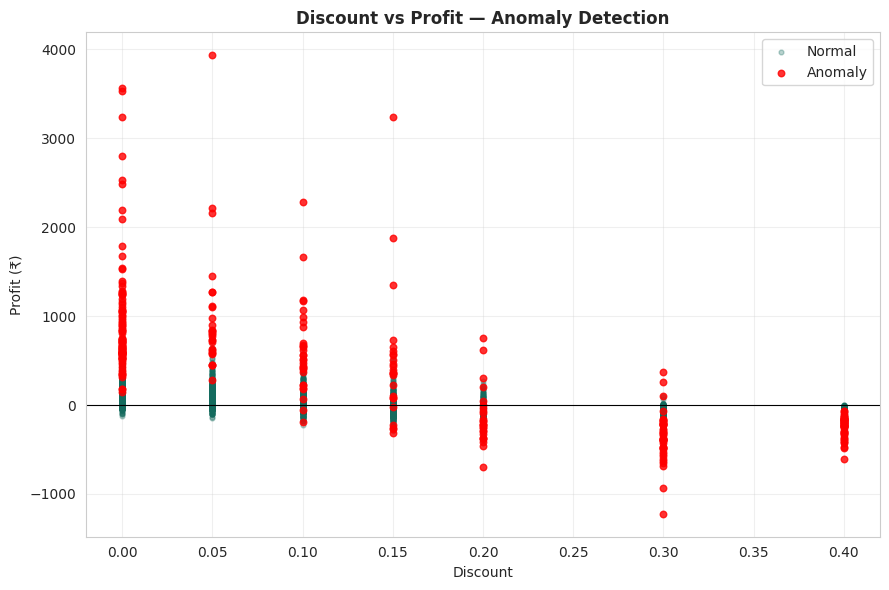

In [12]:
from sklearn.ensemble import IsolationForest

anomaly_features = ["Sales", "Quantity", "Discount", "Profit"]
Xa = df[anomaly_features].copy()

iso = IsolationForest(contamination=0.03, random_state=42, n_estimators=200)
df["AnomalyFlag"] = iso.fit_predict(Xa)
df["AnomalyScore"] = iso.decision_function(Xa)

n_anom = (df["AnomalyFlag"] == -1).sum()
print(f"Anomalous transactions flagged: {n_anom:,} ({n_anom/len(df)*100:.1f}% of all orders)")

fig, ax = plt.subplots(figsize=(9,6))
normal = df[df["AnomalyFlag"]==1]
anom   = df[df["AnomalyFlag"]==-1]
ax.scatter(normal["Discount"], normal["Profit"], s=12, alpha=0.3, color=PRIMARY, label="Normal")
ax.scatter(anom["Discount"], anom["Profit"], s=22, alpha=0.8, color="red", label="Anomaly")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Discount"); ax.set_ylabel("Profit (₹)")
ax.set_title("Discount vs Profit — Anomaly Detection", fontweight="bold")
ax.legend()
plt.tight_layout(); plt.show()


## 11. ML Module 6 — Revenue Forecasting (Holt-Winters Exponential Smoothing)

Decomposes the monthly revenue series into trend + seasonality, then forecasts the next
6 months. Holt-Winters is used for robustness and fast, dependency-light execution.

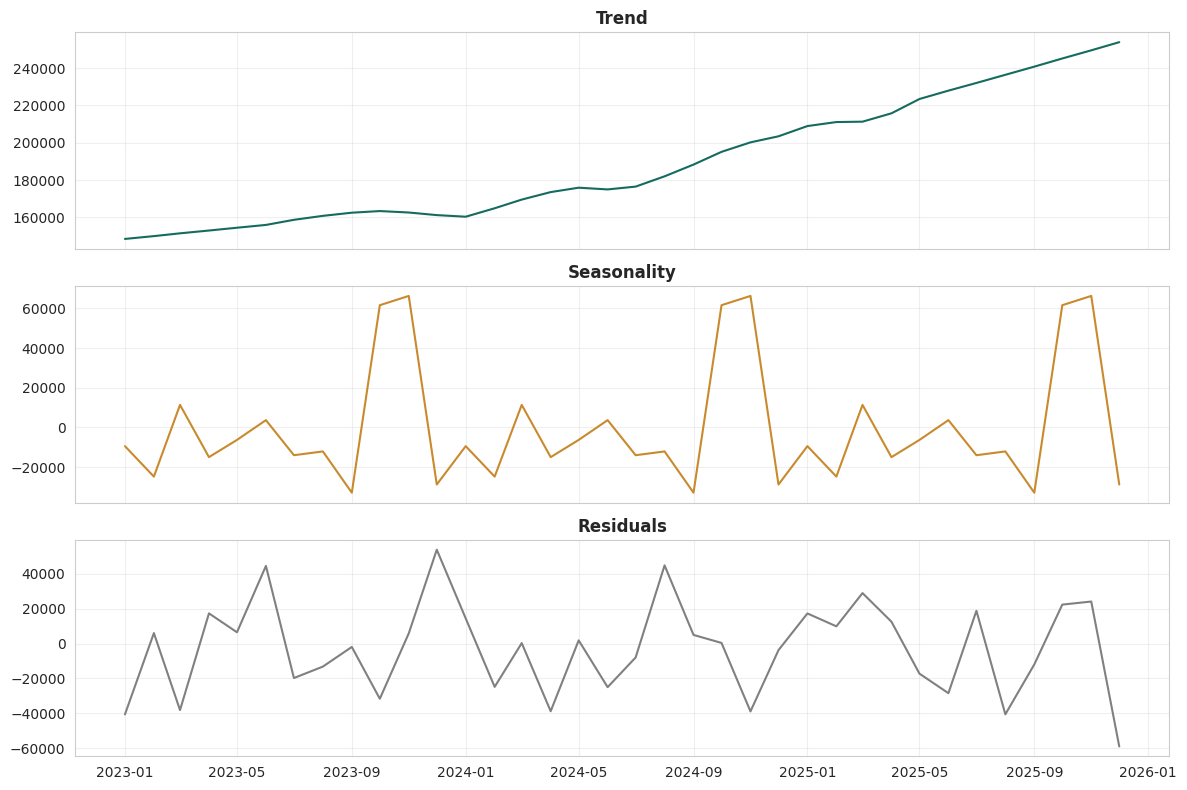

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

ts = df.groupby("YearMonth")["Sales"].sum()
ts.index = pd.PeriodIndex(ts.index, freq="M").to_timestamp()
ts = ts.sort_index()

decomp = seasonal_decompose(ts, model="additive", period=12, extrapolate_trend="freq")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(decomp.trend, color=PRIMARY); axes[0].set_title("Trend", fontweight="bold")
axes[1].plot(decomp.seasonal, color=ACCENT); axes[1].set_title("Seasonality", fontweight="bold")
axes[2].plot(decomp.resid, color="gray"); axes[2].set_title("Residuals", fontweight="bold")
plt.tight_layout(); plt.show()


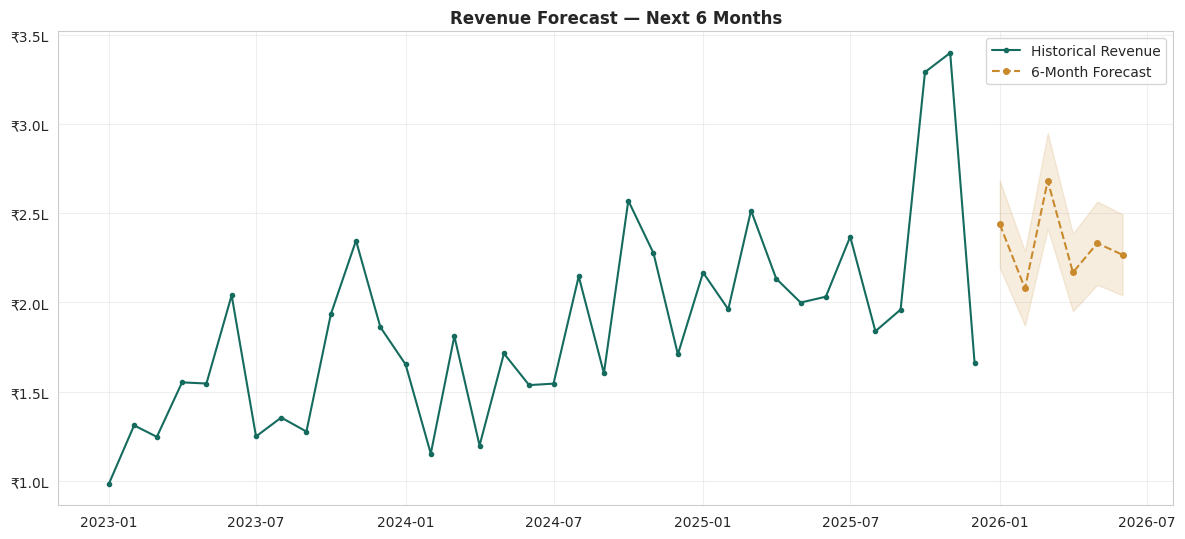

Forecasted monthly revenue:
  Jan 2026: ₹243,908
  Feb 2026: ₹207,839
  Mar 2026: ₹268,197
  Apr 2026: ₹216,806
  May 2026: ₹233,227
  Jun 2026: ₹226,726


In [14]:
model = ExponentialSmoothing(ts, trend="add", seasonal="add", seasonal_periods=12).fit()
forecast = model.forecast(6)

fig, ax = plt.subplots(figsize=(12,5.5))
ax.plot(ts.index, ts.values, color=PRIMARY, marker="o", markersize=3, label="Historical Revenue")
ax.plot(forecast.index, forecast.values, color=ACCENT, marker="o", markersize=4, ls="--", label="6-Month Forecast")
ax.fill_between(forecast.index, forecast.values*0.9, forecast.values*1.1, color=ACCENT, alpha=0.15)
ax.set_title("Revenue Forecast — Next 6 Months", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{x/1e5:.1f}L"))
ax.legend()
plt.tight_layout(); plt.show()

print("Forecasted monthly revenue:")
for d, v in forecast.items():
    print(f"  {d.strftime('%b %Y')}: ₹{v:,.0f}")


## 12. Cohort Retention Analysis

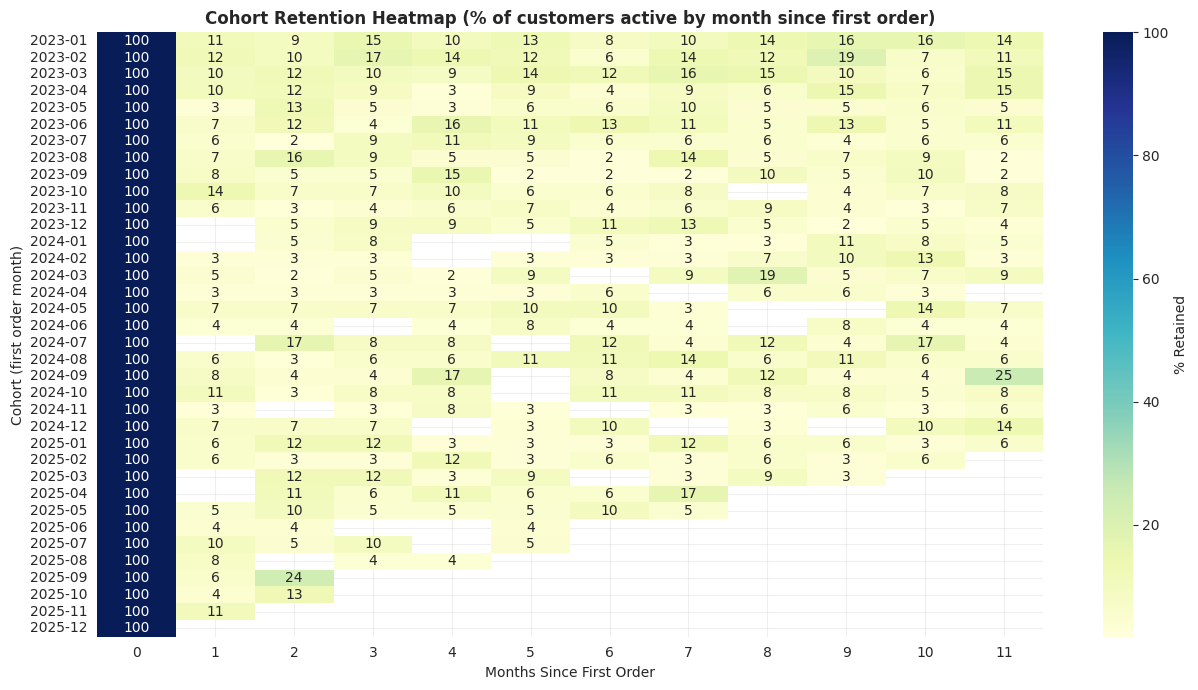

In [15]:
order_first = df.groupby("Customer ID")["Order Date"].min().dt.to_period("M")
df["CohortMonth"] = df["Customer ID"].map(order_first)
df["OrderMonth"]  = df["Order Date"].dt.to_period("M")
df["CohortIndex"] = (df["OrderMonth"] - df["CohortMonth"]).apply(lambda x: x.n)

cohort_data = df.groupby(["CohortMonth","CohortIndex"])["Customer ID"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="Customer ID")
cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

fig, ax = plt.subplots(figsize=(13,7))
sns.heatmap(retention.iloc[:, :12], annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label":"% Retained"})
ax.set_title("Cohort Retention Heatmap (% of customers active by month since first order)", fontweight="bold")
ax.set_xlabel("Months Since First Order"); ax.set_ylabel("Cohort (first order month)")
plt.tight_layout(); plt.show()


## 13. Geographic Performance

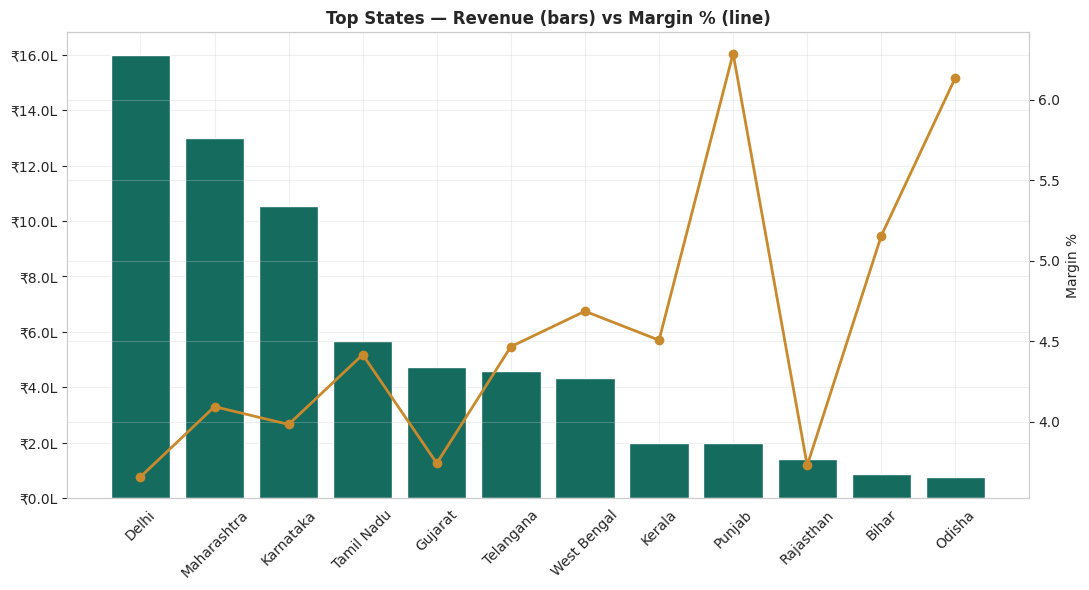

In [16]:
state_perf = df.groupby("State").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).reset_index()
state_perf["Margin"] = state_perf["Profit"]/state_perf["Sales"]*100
state_perf = state_perf.sort_values("Sales", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11,6))
bars = ax.bar(state_perf["State"], state_perf["Sales"], color=PRIMARY)
ax2 = ax.twinx()
ax2.plot(state_perf["State"], state_perf["Margin"], color=ACCENT, marker="o", lw=2)
ax.set_title("Top States — Revenue (bars) vs Margin % (line)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{x/1e5:.1f}L"))
ax2.set_ylabel("Margin %")
plt.tight_layout(); plt.show()


## 14. Business Health Scorecard (Composite Index)

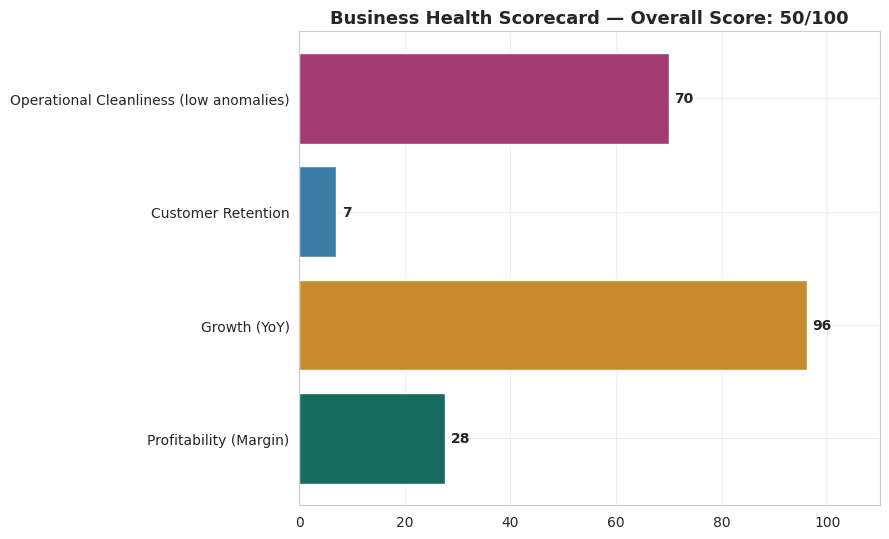


  OVERALL BUSINESS HEALTH SCORE: 50.2 / 100


In [17]:
margin_score   = min(100, max(0, kpis["Avg Margin %"] / 15 * 100))
growth = df.groupby("Year")["Sales"].sum()
growth_pct = (growth.iloc[-1]/growth.iloc[0] - 1) * 100 if len(growth) > 1 else 0
growth_score = min(100, max(0, 50 + growth_pct))
retention_score = min(100, max(0, retention.iloc[:, 1].mean())) if retention.shape[1] > 1 else 50
anomaly_score = max(0, 100 - (n_anom/len(df)*100)*10)

health_components = {
    "Profitability (Margin)": margin_score,
    "Growth (YoY)": growth_score,
    "Customer Retention": retention_score,
    "Operational Cleanliness (low anomalies)": anomaly_score,
}
overall_health = np.mean(list(health_components.values()))

fig, ax = plt.subplots(figsize=(9,5.5))
bars = ax.barh(list(health_components.keys()), list(health_components.values()), color=PALETTE[:4])
for bar, val in zip(bars, health_components.values()):
    ax.text(val+1, bar.get_y()+bar.get_height()/2, f"{val:.0f}", va="center", fontweight="bold")
ax.set_xlim(0,110)
ax.set_title(f"Business Health Scorecard — Overall Score: {overall_health:.0f}/100", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

print(f"\n{'='*55}")
print(f"  OVERALL BUSINESS HEALTH SCORE: {overall_health:.1f} / 100")
print(f"{'='*55}")


## 15. Automated Executive Narrative

In [18]:
best_cat = cat.sort_values('Profit', ascending=False).index[0]
worst_band = db.sort_values('Margin').iloc[0]
top_state = state_perf.iloc[0]['State']
champions_n = (cust['Segment_Label']=='Champions').sum()
at_risk_n = (cust['Churned']==1).sum()

narrative = f"""
PROFITARA — EXECUTIVE SUMMARY
{'='*60}
• Total revenue of ₹{kpis['Total Revenue (₹)']:,.0f} was generated across {kpis['Total Orders']:,} orders
  from {kpis['Total Customers']:,} customers, at an average margin of {kpis['Avg Margin %']:.1f}%.

• '{best_cat}' is the strongest profit-driving category. The discount band
  '{worst_band['DiscountBand']}' shows the weakest average margin ({worst_band['Margin']*100:.1f}%),
  indicating discount strategy should be revisited there.

• '{top_state}' leads all states by revenue.

• Customer segmentation (K-Means, k={best_k}) identifies {champions_n} "Champion" customers
  driving disproportionate value — prioritize retention offers for this group.

• {at_risk_n} customers ({at_risk_n/len(cust)*100:.1f}% of base) are flagged as churn-risk
  (recency above the 75th percentile) — target with win-back campaigns
  (model AUC = {roc_auc:.2f}).

• Market basket analysis surfaced {len(rules)} cross-sell rules; the top rule has a lift
  of {rules.iloc[0]['lift']:.2f}, suggesting strong bundling opportunity.

• {n_anom} transactions ({n_anom/len(df)*100:.1f}%) were flagged as anomalous and merit
  manual discount-abuse review.

• Overall Business Health Score: {overall_health:.0f}/100.
"""
print(narrative)



PROFITARA — EXECUTIVE SUMMARY
• Total revenue of ₹6,695,229 was generated across 4,918 orders
  from 1,448 customers, at an average margin of 4.2%.

• 'Personal Care' is the strongest profit-driving category. The discount band
  '31-40%' shows the weakest average margin (-19.2%),
  indicating discount strategy should be revisited there.

• 'Delhi' leads all states by revenue.

• Customer segmentation (K-Means, k=2) identifies 119 "Champion" customers
  driving disproportionate value — prioritize retention offers for this group.

• 361 customers (24.9% of base) are flagged as churn-risk
  (recency above the 75th percentile) — target with win-back campaigns
  (model AUC = 0.91).

• Market basket analysis surfaced 52 cross-sell rules; the top rule has a lift
  of 9.58, suggesting strong bundling opportunity.

• 300 transactions (3.0%) were flagged as anomalous and merit
  manual discount-abuse review.

• Overall Business Health Score: 50/100.



## 16. Export Pipeline Outputs

In [19]:
import json

export = {
    "kpis": kpis,
    "best_k_clusters": int(best_k),
    "clv_model_r2": round(float(r2), 3),
    "churn_model_auc": round(float(roc_auc), 3),
    "association_rules_found": int(len(rules)),
    "anomalies_flagged": int(n_anom),
    "business_health_score": round(float(overall_health), 1),
    "forecast_next_6_months": {d.strftime("%Y-%m"): round(float(v),2) for d,v in forecast.items()},
}

with open("profitara_pipeline_results.json", "w") as f:
    json.dump(export, f, indent=2)

cust.to_csv("profitara_customer_segments.csv", index=False)

print("✅ Pipeline complete. Exported:")
print("   - profitara_pipeline_results.json")
print("   - profitara_customer_segments.csv")


✅ Pipeline complete. Exported:
   - profitara_pipeline_results.json
   - profitara_customer_segments.csv
